# ICA — Full Scale End-to-End Data Science Pipeline
## Synthetic Dataset — Target Default ≈ 7%

**Project:** Intelligence Credit Analyst (ICA)

### Pipeline
1. Pre-Processing
2. EDA
3. Feature Engineering
4. Feature Selection
5. Temporal Train / Validation / Test Split
6. Baseline Modeling
7. Feature-Engineered Modeling
8. Model Evaluation
9. Feature Importance

### Models
- Logistic Regression
- Random Forest
- XGBoost

### Metrics
- F1
- ROC-AUC
- PR-AUC
- Precision
- Recall
- Accuracy

> EDA cells contain plotting code only. Run the notebook in your IDE/Jupyter to see the visualizations.

In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
CUDA version: 13.0


## 1. Setup & Load Data

In [2]:
# ============================================================
# 1. SETUP & LOAD DATA
# Google Colab + A100
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# INSTALL / IMPORT DEPENDENCIES
# ============================================================

# gdown untuk download file dari Google Drive
!pip -q install gdown

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# XGBOOST
# ============================================================

try:
    from xgboost import XGBClassifier
    import xgboost as xgb
    
    XGB_AVAILABLE = True
    XGB_VERSION = xgb.__version__

except ImportError:
    XGB_AVAILABLE = False
    XGB_VERSION = None

# ============================================================
# DISPLAY SETTINGS
# ============================================================

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

# ============================================================
# GOOGLE DRIVE FILE
# ============================================================

# GANTI dengan FILE ID Google Drive lu
# Contoh:
# https://drive.google.com/file/d/1AbCdEfGhIjKlMnOP/view
# FILE_ID = "1AbCdEfGhIjKlMnOP"

FILE_ID = "12pn5p6QqP-bFB0L1mpLsrh96sPjwUcyK"

# Nama file setelah didownload ke Colab
DATA_ZIP = Path("/content/ICA_Raw.zip")

# ============================================================
# DOWNLOAD DATASET
# ============================================================

download_url = f"https://drive.google.com/uc?id={FILE_ID}"

print("Downloading dataset from Google Drive...")
print("Destination:", DATA_ZIP)

!gdown "{download_url}" -O "{DATA_ZIP}"

# ============================================================
# VALIDATE DOWNLOAD
# ============================================================

if not DATA_ZIP.exists():
    raise FileNotFoundError(
        f"Dataset tidak ditemukan setelah download: {DATA_ZIP}"
    )

print("\nDataset downloaded successfully!")
print("Dataset path :", DATA_ZIP)
print("Dataset size :", round(DATA_ZIP.stat().st_size / (1024**2), 2), "MB")

# ============================================================
# OUTPUT DIRECTORY
# ============================================================

OUT_DIR = Path("/content/ICA_FullScale_7pct_Notebook_Outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("\nOutput directory:")
print(OUT_DIR)

# ============================================================
# INSPECT ZIP CONTENT
# ============================================================

with zipfile.ZipFile(DATA_ZIP, "r") as z:

    files = z.namelist()

    print("\nFiles inside ZIP:")
    for f in files:
        print(" -", f)

# ============================================================
# HELPER:
# FIND FILE INSIDE ZIP
# ============================================================

def find_zip_file(files, filename):
    """
    Cari filename di dalam ZIP.
    Bisa menangani ZIP dengan atau tanpa root folder.
    """

    matches = [
        f for f in files
        if Path(f).name == filename
    ]

    if len(matches) == 0:
        raise FileNotFoundError(
            f"{filename} tidak ditemukan di dalam ZIP."
        )

    if len(matches) > 1:
        raise ValueError(
            f"Ditemukan lebih dari satu {filename} di dalam ZIP:\n"
            + "\n".join(matches)
        )

    return matches[0]


# ============================================================
# LOAD DATA FROM ZIP
# ============================================================

with zipfile.ZipFile(DATA_ZIP, "r") as z:

    files = z.namelist()

    customer_file = find_zip_file(
        files,
        "customer_profile.csv"
    )

    account_file = find_zip_file(
        files,
        "credit_account.csv"
    )

    behavior_file = find_zip_file(
        files,
        "monthly_behavior.csv"
    )

    print("\nLoading:")
    print("Customer :", customer_file)
    print("Account  :", account_file)
    print("Behavior :", behavior_file)

    customer = pd.read_csv(
        z.open(customer_file),
        parse_dates=["customer_since"]
    )

    account = pd.read_csv(
        z.open(account_file)
    )

    behavior = pd.read_csv(
        z.open(behavior_file),
        parse_dates=["snapshot_date"]
    )

# ============================================================
# BASIC DATA CHECK
# ============================================================

print("\n" + "=" * 60)
print("DATA LOADED SUCCESSFULLY")
print("=" * 60)

print("\nCustomer Profile :", customer.shape)
print("Credit Account   :", account.shape)
print("Monthly Behavior :", behavior.shape)

print(
    "\nDefault rate:",
    round(
        behavior["default_next_3m"].mean() * 100,
        2
    ),
    "%"
)

print(
    "Deterioration rate:",
    round(
        behavior["deterioration_next_1m"].mean() * 100,
        2
    ),
    "%"
)

print("XGBoost:", XGB_AVAILABLE)

Destination: /content/ICA_Raw.zip
Downloading...
From: https://drive.google.com/uc?id=12pn5p6QqP-bFB0L1mpLsrh96sPjwUcyK
To: /content/ICA_Raw.zip
100% 8.25M/8.25M [00:00<00:00, 19.0MB/s]

Dataset downloaded successfully!
Dataset path : /content/ICA_Raw.zip
Dataset size : 7.87 MB

Output directory:
/content/ICA_FullScale_7pct_Notebook_Outputs

Files inside ZIP:
 - monthly_behavior.csv
 - credit_account.csv
 - data_dictionary.csv
 - customer_profile.csv

Loading:
Customer : customer_profile.csv
Account  : credit_account.csv
Behavior : monthly_behavior.csv

DATA LOADED SUCCESSFULLY

Customer Profile : (10000, 13)
Credit Account   : (16794, 12)
Monthly Behavior : (240000, 17)

Default rate: 6.93 %
Deterioration rate: 41.4 %
XGBoost: True


## 2. Pre-Processing

In [3]:
def standardize_columns(df):
    x=df.copy()
    x.columns=(x.columns.str.strip().str.lower()
               .str.replace(" ","_")
               .str.replace(r"[^a-z0-9_]","",regex=True))
    return x

customer=standardize_columns(customer)
account=standardize_columns(account)
behavior=standardize_columns(behavior)

# Remove exact duplicates and enforce monthly grain
print("Exact duplicates:")
print("Customer:",customer.duplicated().sum())
print("Account:",account.duplicated().sum())
print("Behavior:",behavior.duplicated().sum())

customer=customer.drop_duplicates()
account=account.drop_duplicates()
behavior=behavior.drop_duplicates(["customer_id","snapshot_date"])

# Relationship checks
print("\nRelationship checks")
print("Account customer IDs missing from profile:",
      (~account.customer_id.isin(customer.customer_id)).sum())
print("Behavior customer IDs missing from profile:",
      (~behavior.customer_id.isin(customer.customer_id)).sum())
print("Duplicate customer-month:",
      behavior.duplicated(["customer_id","snapshot_date"]).sum())

# Missingness
missing_report=pd.DataFrame({
    "customer_missing_pct":customer.isna().mean()*100,
    "account_missing_pct":account.isna().mean()*100,
    "behavior_missing_pct":behavior.isna().mean()*100
})
display(missing_report.sort_values("behavior_missing_pct",ascending=False))

Exact duplicates:
Customer: 0
Account: 0
Behavior: 0

Relationship checks
Account customer IDs missing from profile: 0
Behavior customer IDs missing from profile: 0
Duplicate customer-month: 0


,customer_missing_pct,account_missing_pct,behavior_missing_pct
default_next_3m,NaN,NaN,12.500000
deterioration_next_1m,NaN,NaN,4.166667
active_credit_accounts,NaN,NaN,0.000000
customer_id,0.0,0.0,0.000000
dpd,NaN,NaN,0.000000
dsr,NaN,NaN,0.000000
dti,NaN,NaN,0.000000
late_payment_count_3m,NaN,NaN,0.000000
missed_payment_count_3m,NaN,NaN,0.000000
monthly_debt_payment,NaN,NaN,0.000000


In [4]:
# Range validation
checks={
"age_valid":customer.age.between(18,100).all(),
"income_positive":customer.monthly_income.gt(0).all(),
"credit_limit_nonnegative":account.credit_limit.ge(0).all(),
"outstanding_nonnegative":account.current_outstanding.ge(0).all(),
"dti_nonnegative":behavior.dti.ge(0).all(),
"dpd_nonnegative":behavior.dpd.ge(0).all(),
"payment_ratio_range":behavior.payment_ratio.between(0,1.1).all(),
"utilization_nonnegative":behavior.utilization.ge(0).all()
}
display(pd.DataFrame({"check":checks.keys(),"pass":checks.values()}))

,check,pass
0,age_valid,True
1,income_positive,True
2,credit_limit_nonnegative,True
3,outstanding_nonnegative,True
4,dti_nonnegative,True
5,dpd_nonnegative,True
6,payment_ratio_range,True
7,utilization_nonnegative,True


### Pre-processing decision

- ID dan relationship dijaga.
- Duplicate customer-month dihapus setelah dicek.
- Missing target pada future periods dianggap valid karena outcome memang belum diketahui.
- **Tidak melakukan global imputation sebelum split**. Imputation dilakukan di model pipeline agar tidak leakage.

## 3. EDA

EDA di bawah ini adalah **code-only**. Jalankan cell di IDE untuk melihat plot.

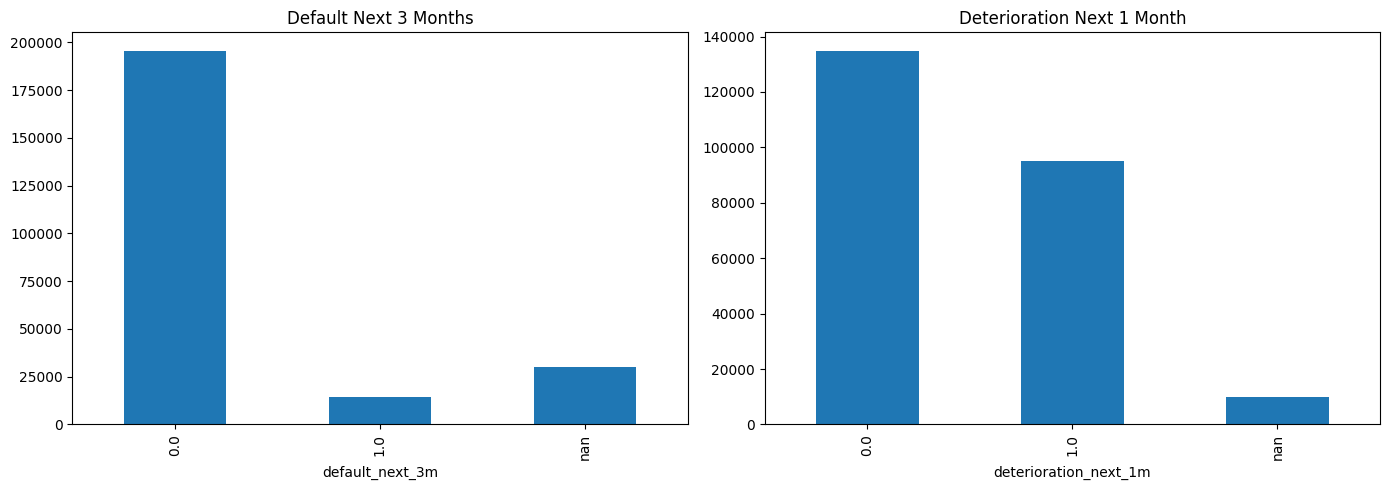

In [5]:
# Target distribution
fig,ax=plt.subplots(1,2,figsize=(14,5))
behavior.default_next_3m.value_counts(dropna=False).sort_index().plot(kind="bar",ax=ax[0])
ax[0].set_title("Default Next 3 Months")
behavior.deterioration_next_1m.value_counts(dropna=False).sort_index().plot(kind="bar",ax=ax[1])
ax[1].set_title("Deterioration Next 1 Month")
plt.tight_layout(); plt.show()

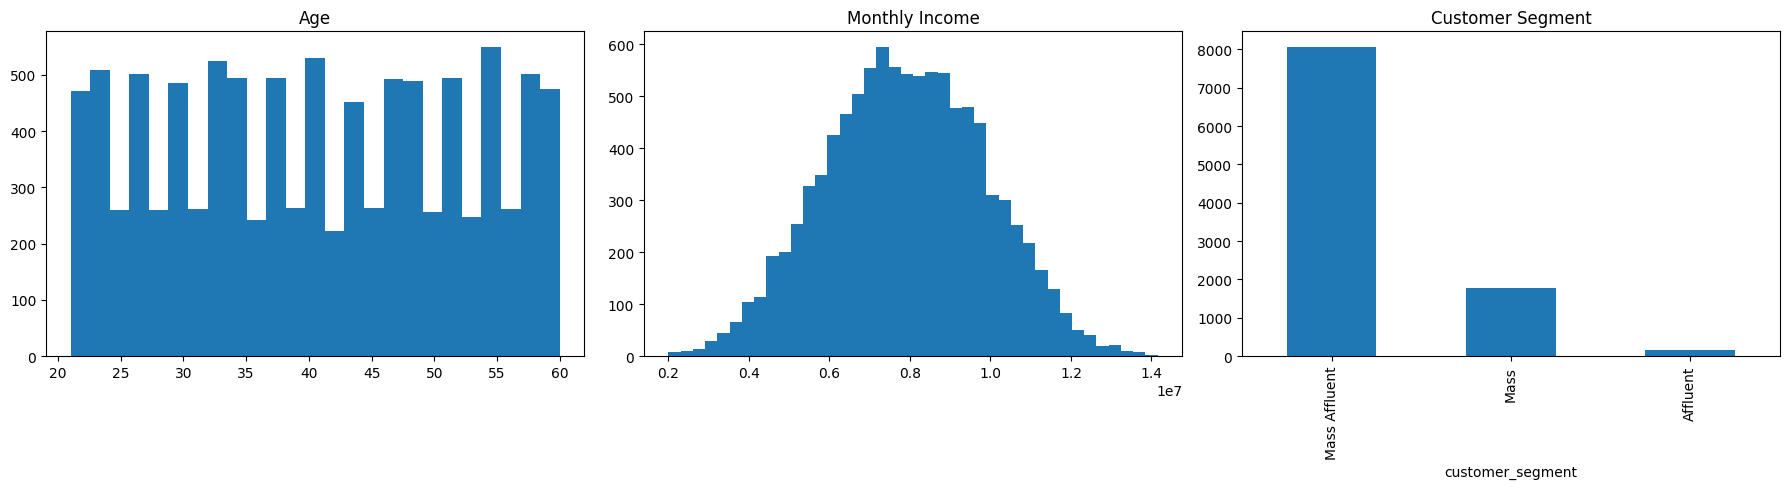

In [6]:
# Customer distributions
fig,ax=plt.subplots(1,3,figsize=(18,5))
ax[0].hist(customer.age,bins=25); ax[0].set_title("Age")
ax[1].hist(customer.monthly_income,bins=40); ax[1].set_title("Monthly Income")
customer.customer_segment.value_counts().plot(kind="bar",ax=ax[2]); ax[2].set_title("Customer Segment")
plt.tight_layout(); plt.show()

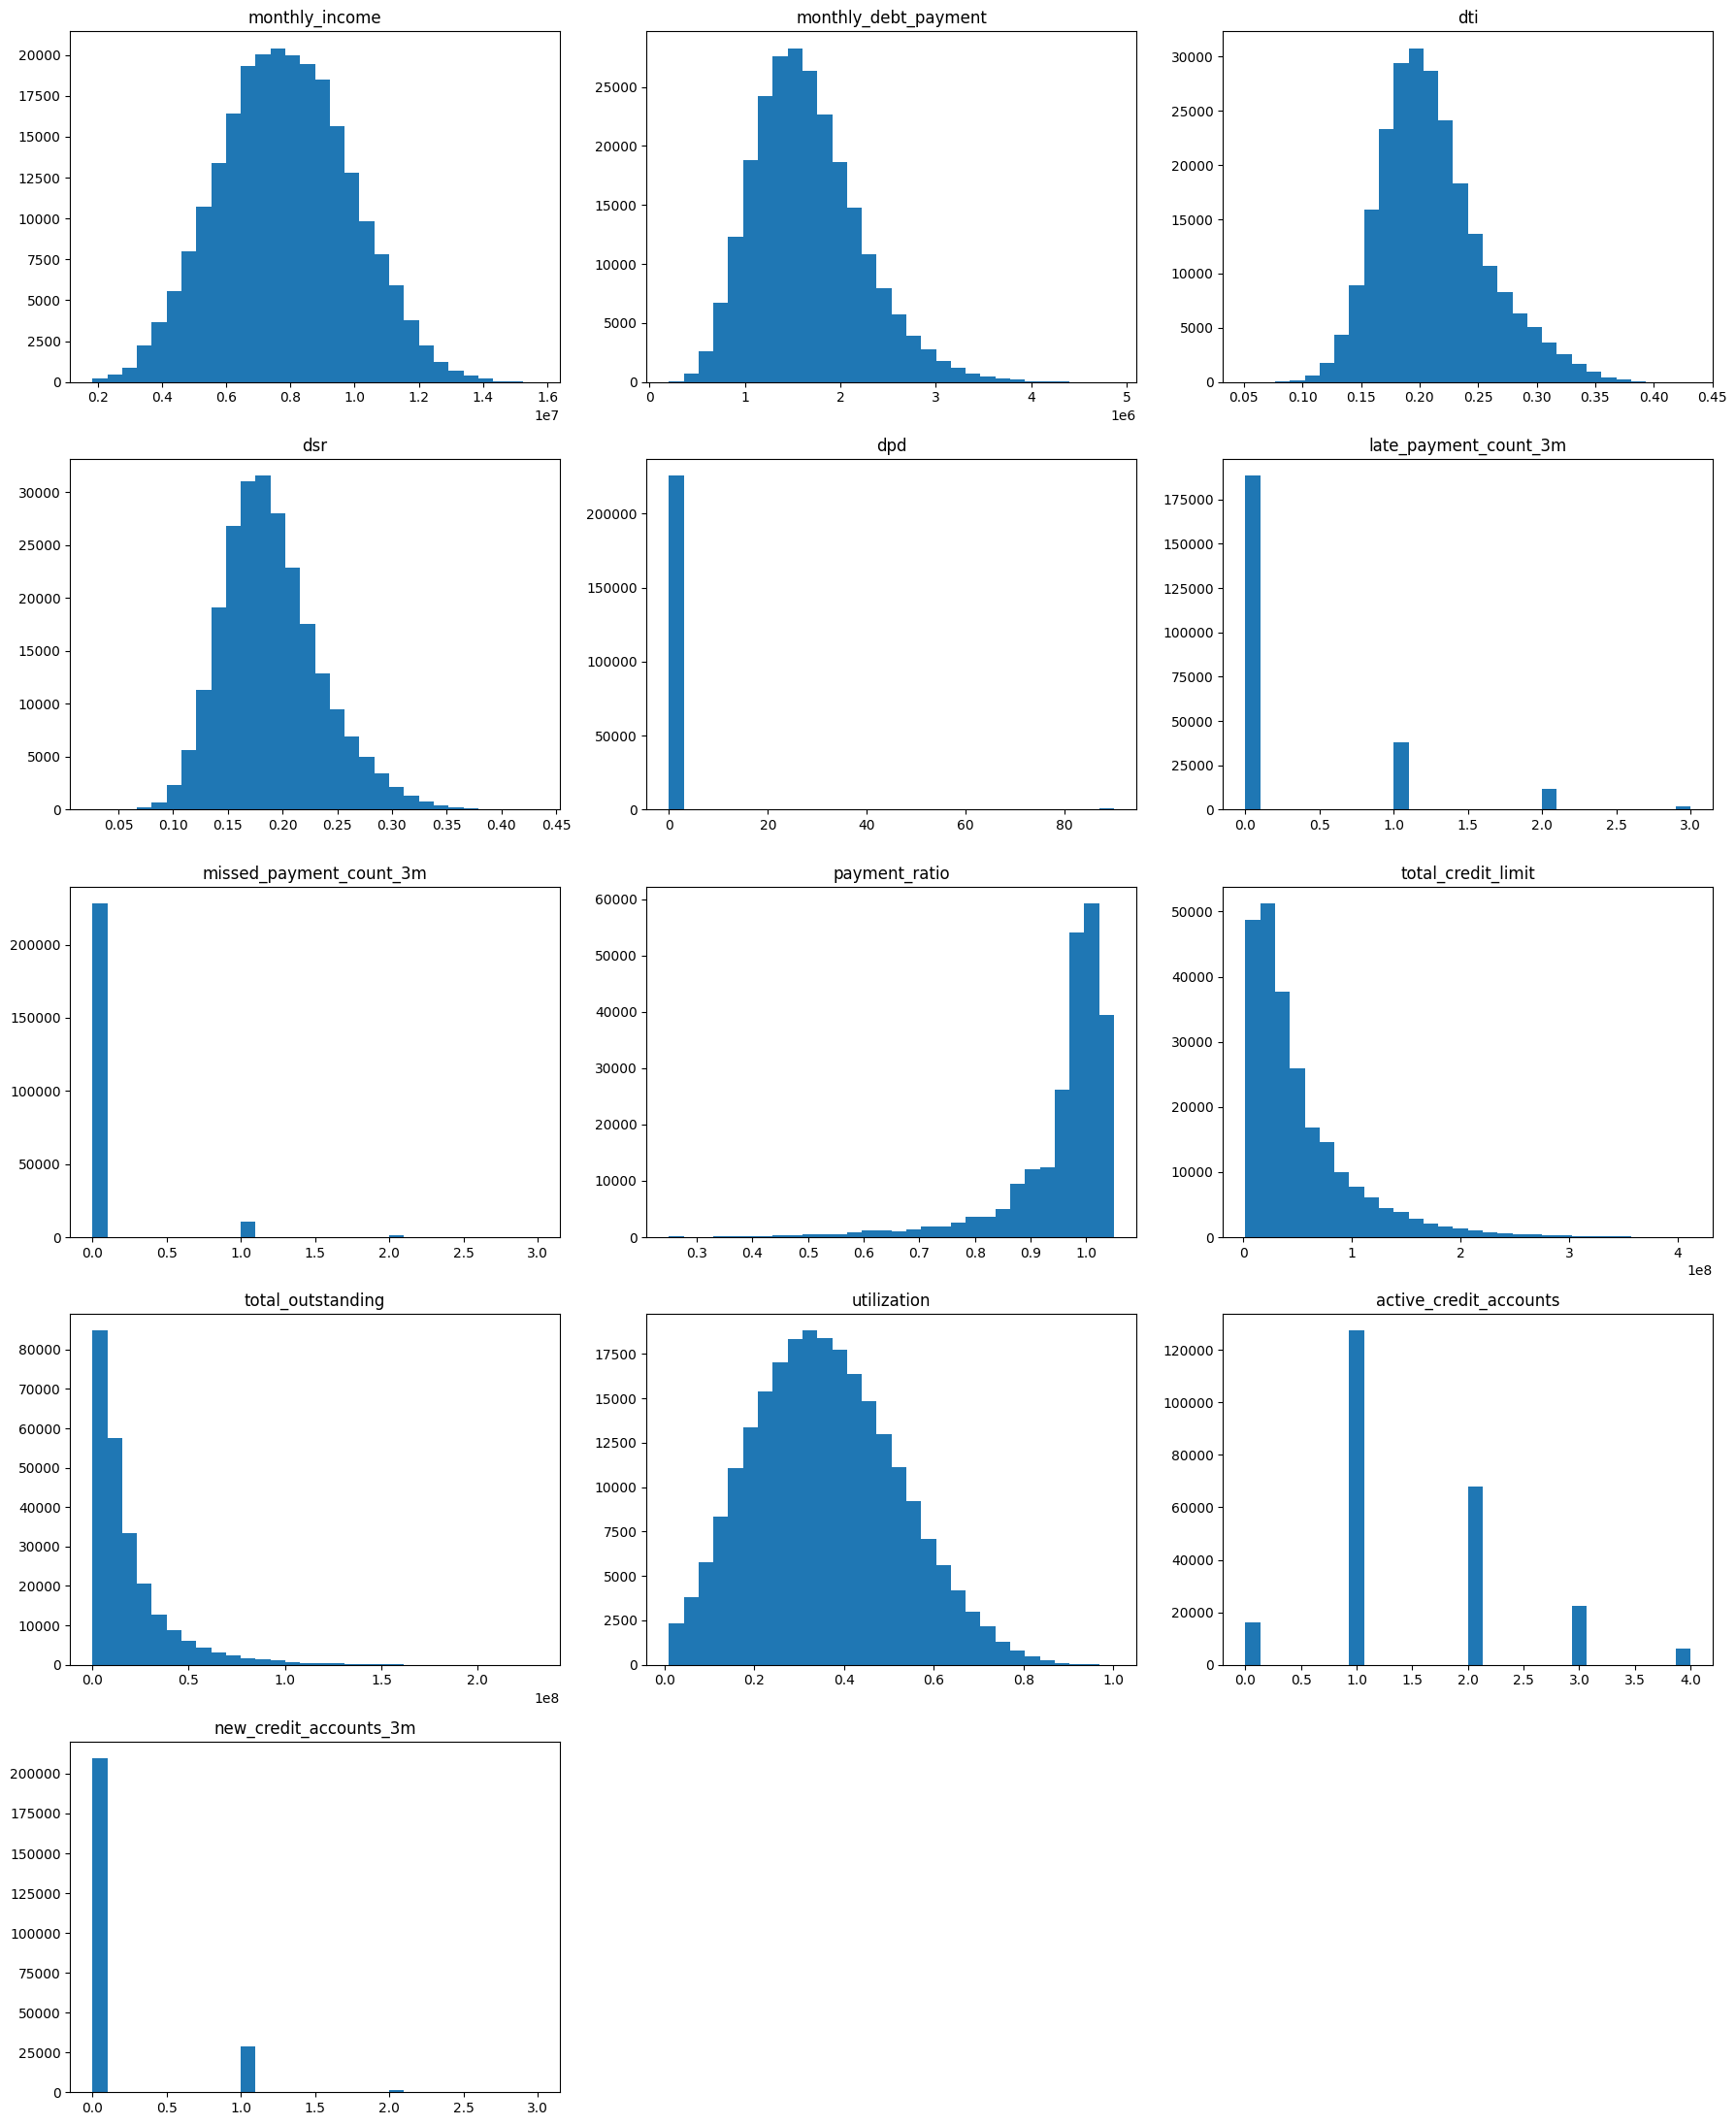

In [7]:
# Risk variable distributions
cols=["monthly_income","monthly_debt_payment","dti","dsr","dpd",
      "late_payment_count_3m","missed_payment_count_3m","payment_ratio",
      "total_credit_limit","total_outstanding","utilization",
      "active_credit_accounts","new_credit_accounts_3m"]

fig,axes=plt.subplots(5,3,figsize=(18,22))
for ax,col in zip(axes.flat,cols):
    ax.hist(behavior[col].dropna(),bins=30)
    ax.set_title(col)
for ax in axes.flat[len(cols):]: ax.axis("off")
plt.tight_layout(); plt.show()

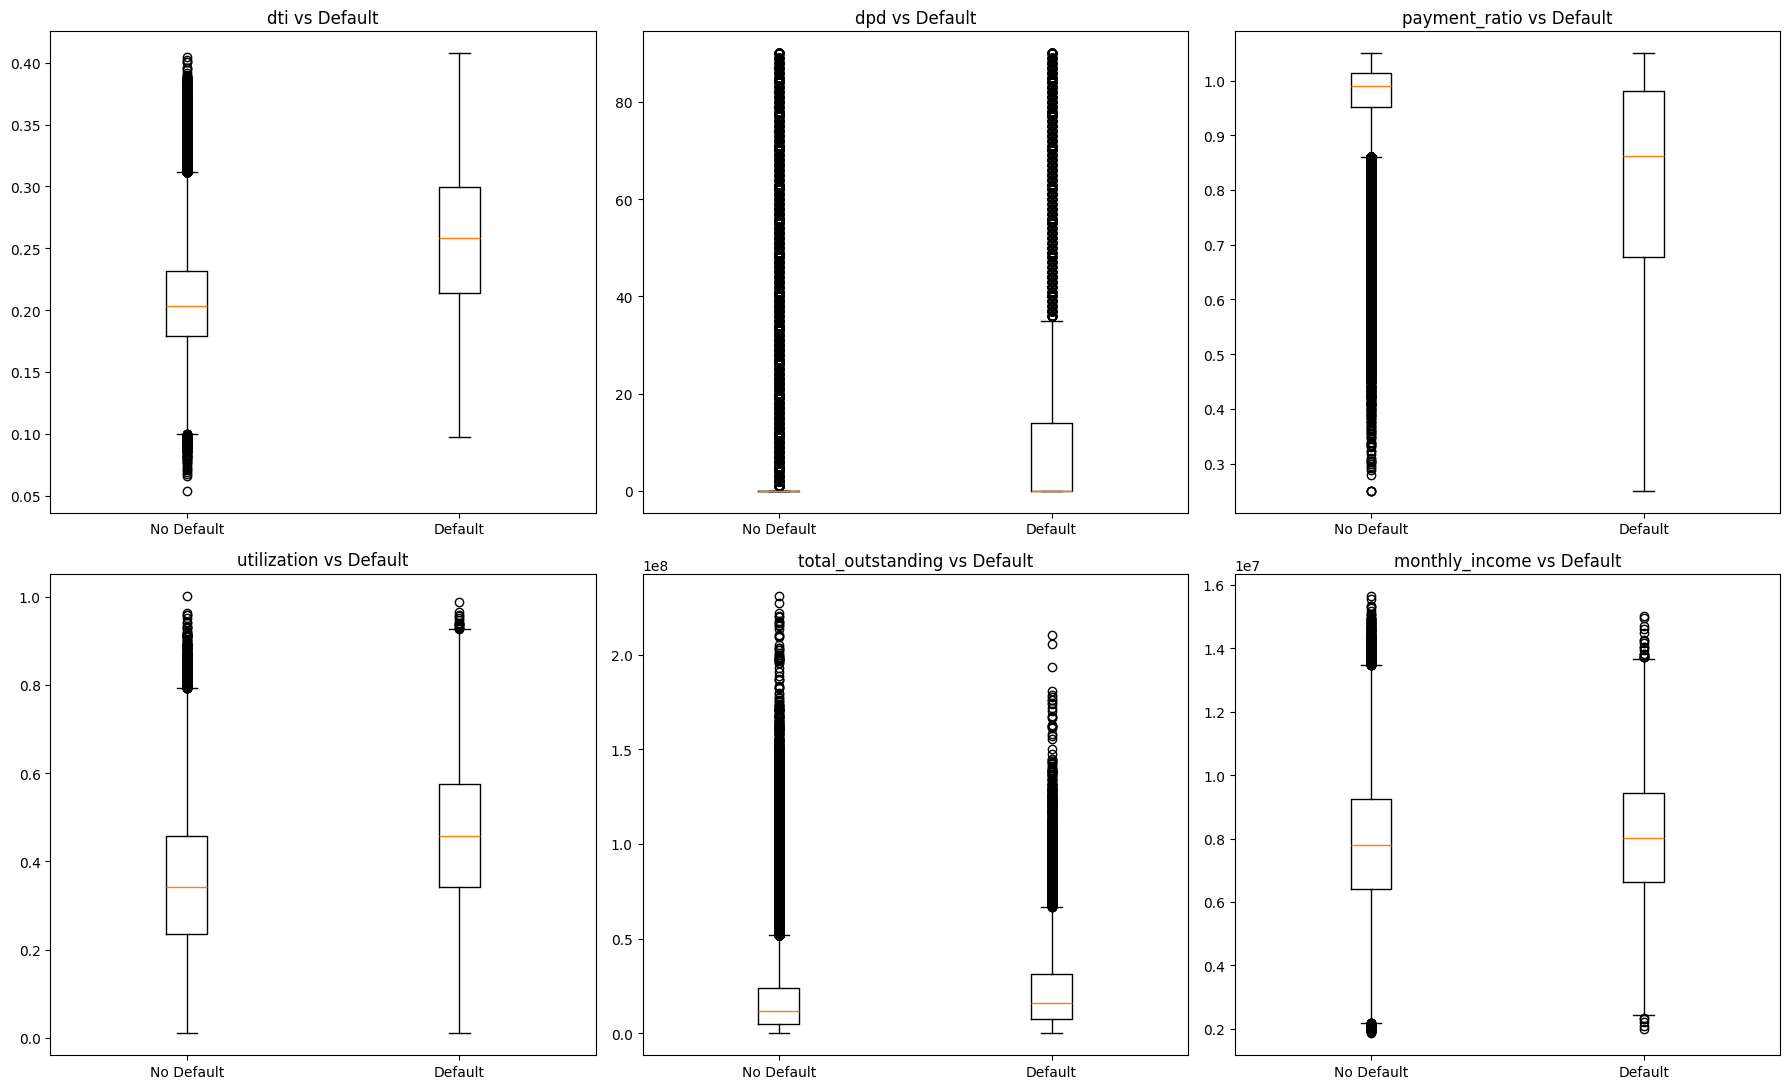

In [8]:
# Default vs key risk variables
cols=["dti","dpd","payment_ratio","utilization","total_outstanding","monthly_income"]
fig,axes=plt.subplots(2,3,figsize=(18,11))
for ax,col in zip(axes.flat,cols):
    groups=[behavior.loc[behavior.default_next_3m==0,col].dropna(),
            behavior.loc[behavior.default_next_3m==1,col].dropna()]
    ax.boxplot(groups,labels=["No Default","Default"])
    ax.set_title(f"{col} vs Default")
plt.tight_layout(); plt.show()

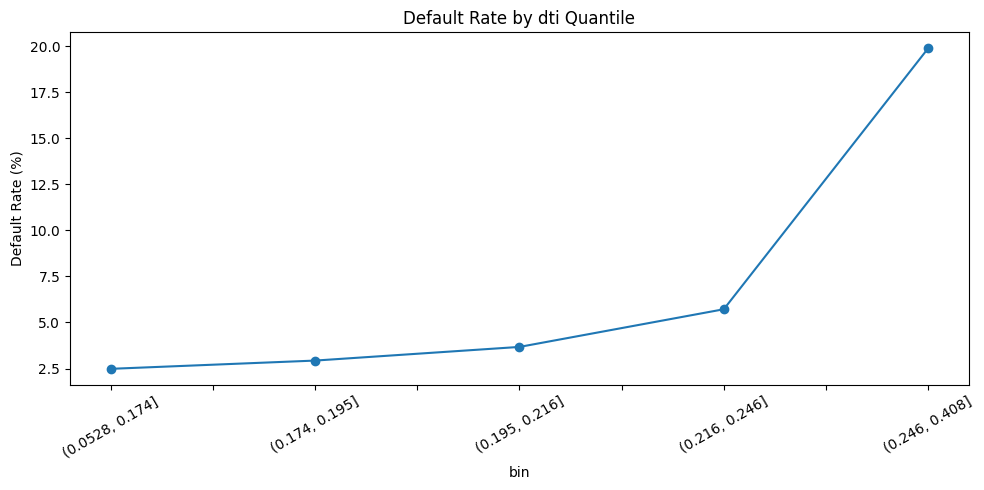

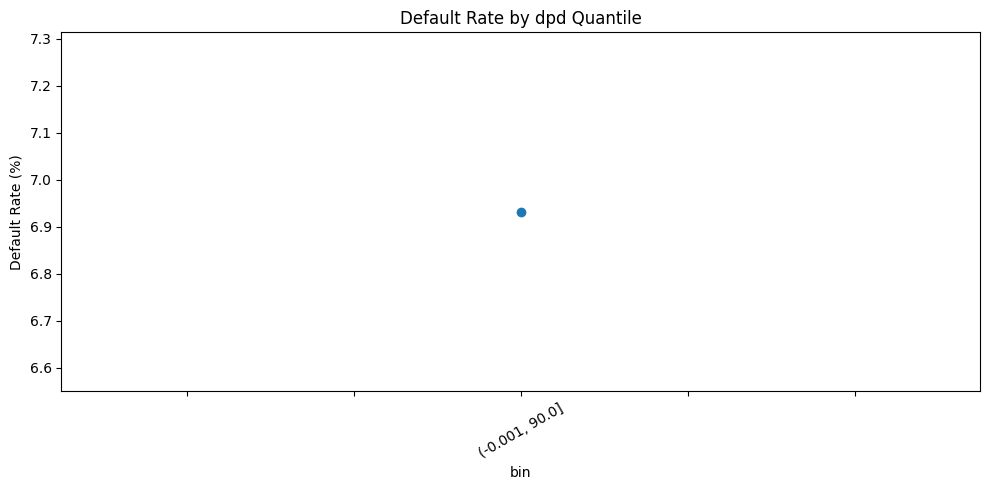

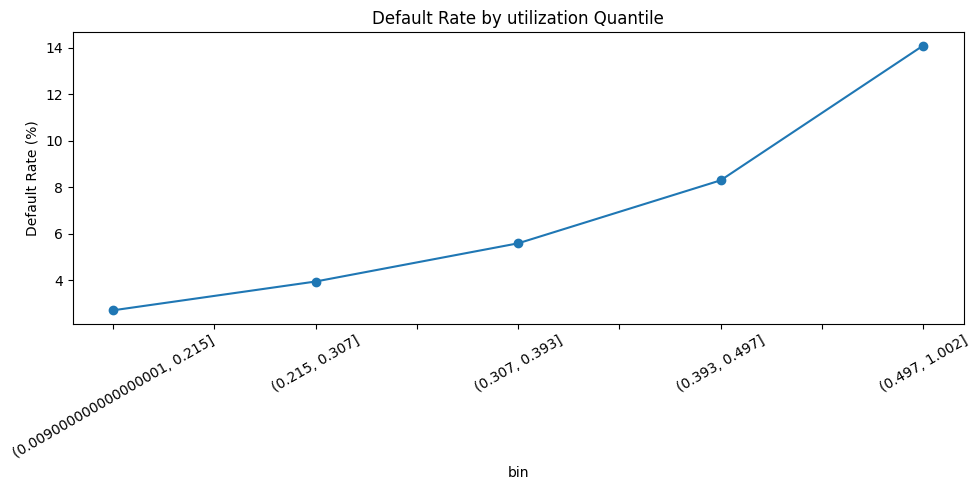

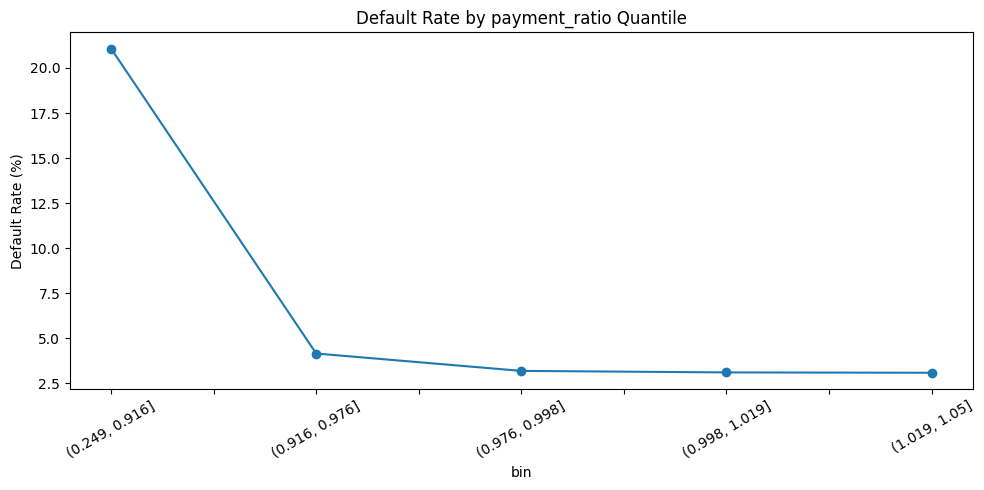

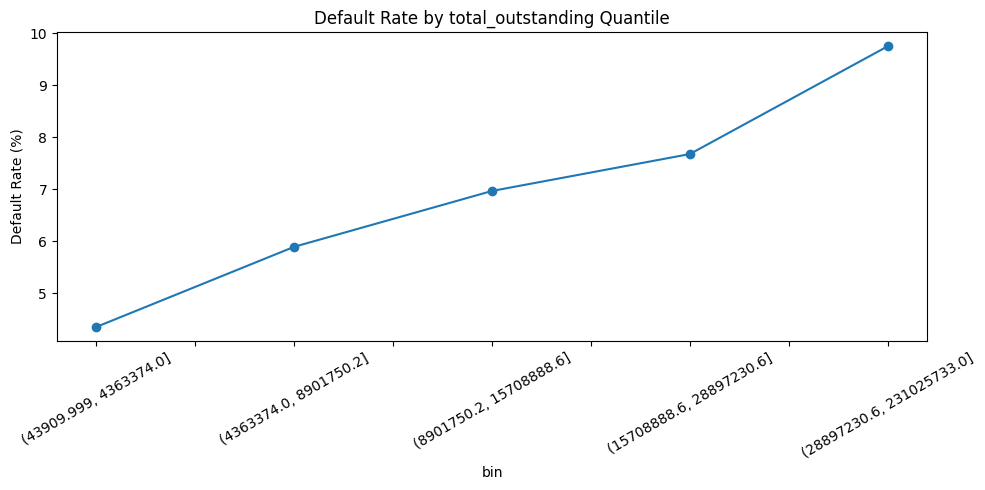

In [9]:
# Default rate by quantile
def plot_default_rate(feature):
    tmp=behavior[[feature,"default_next_3m"]].dropna().copy()
    tmp["bin"]=pd.qcut(tmp[feature],q=5,duplicates="drop")
    rate=tmp.groupby("bin",observed=True).default_next_3m.mean()*100
    rate.plot(kind="line",marker="o",figsize=(10,5),title=f"Default Rate by {feature} Quantile")
    plt.ylabel("Default Rate (%)")
    plt.xticks(rotation=30)
    plt.tight_layout(); plt.show()

for c in ["dti","dpd","utilization","payment_ratio","total_outstanding"]:
    plot_default_rate(c)

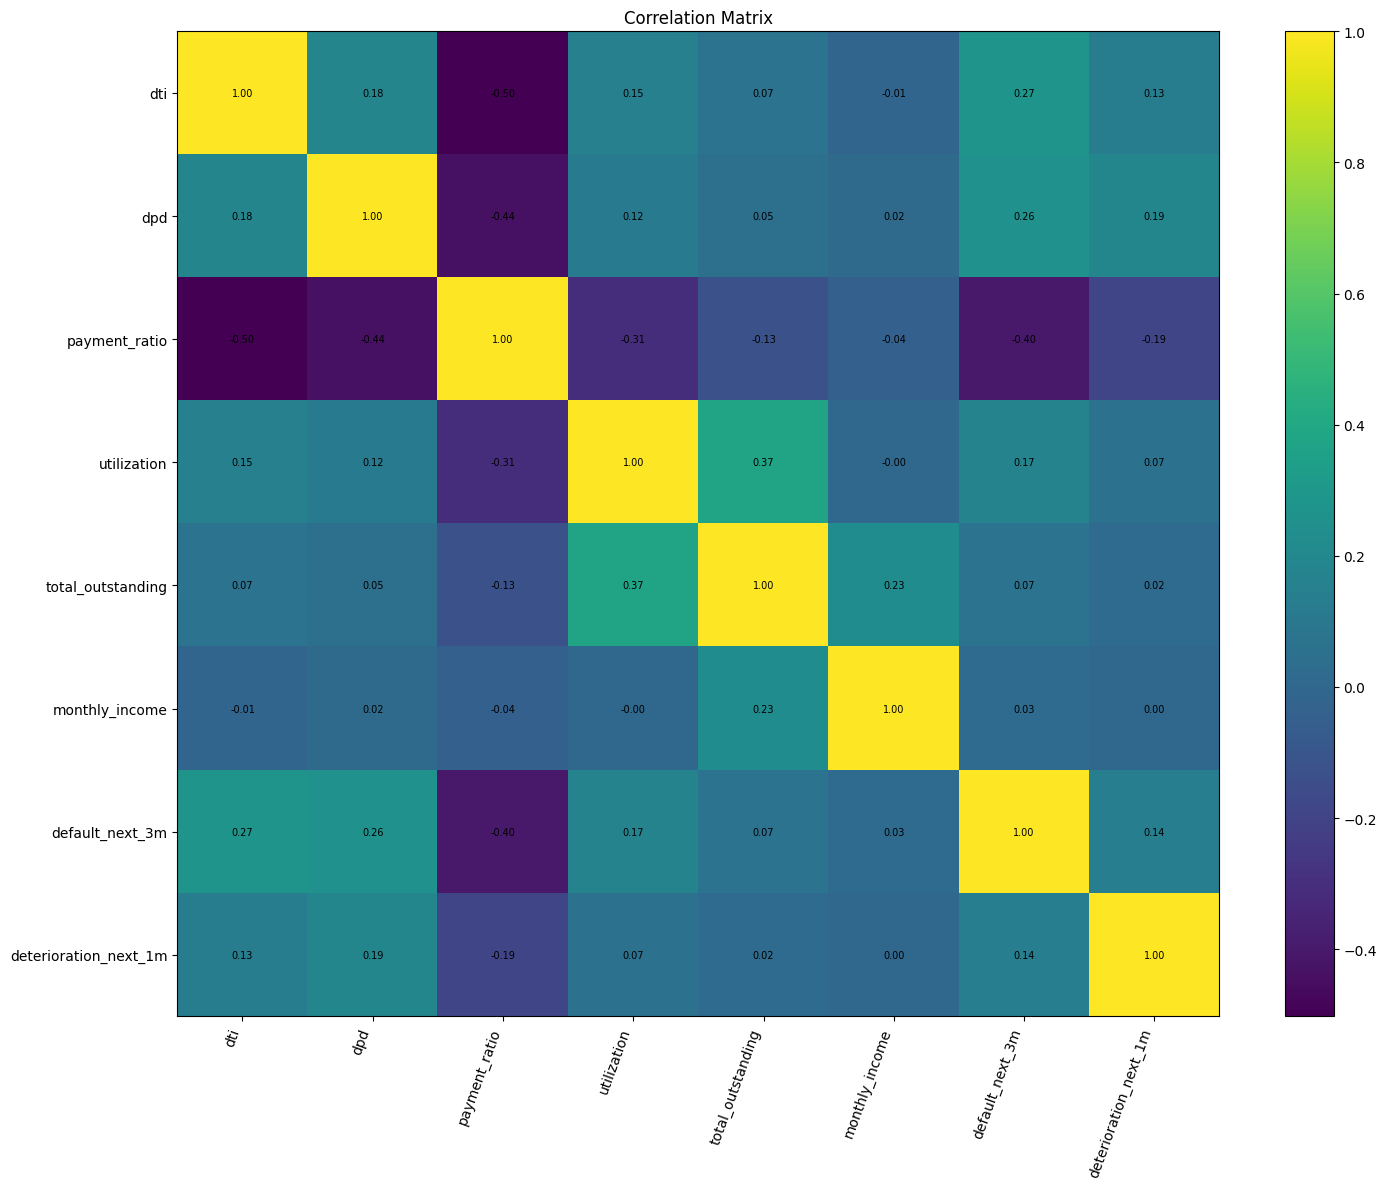

In [10]:
# Correlation
corr_cols=cols+["default_next_3m","deterioration_next_1m"]
corr=behavior[corr_cols].corr()
fig,ax=plt.subplots(figsize=(15,12))
im=ax.imshow(corr,aspect="auto")
ax.set_xticks(range(len(corr_cols))); ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols,rotation=70,ha="right"); ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j,i,f"{corr.iloc[i,j]:.2f}",ha="center",va="center",fontsize=7)
plt.colorbar(im,ax=ax); plt.title("Correlation Matrix"); plt.tight_layout(); plt.show()

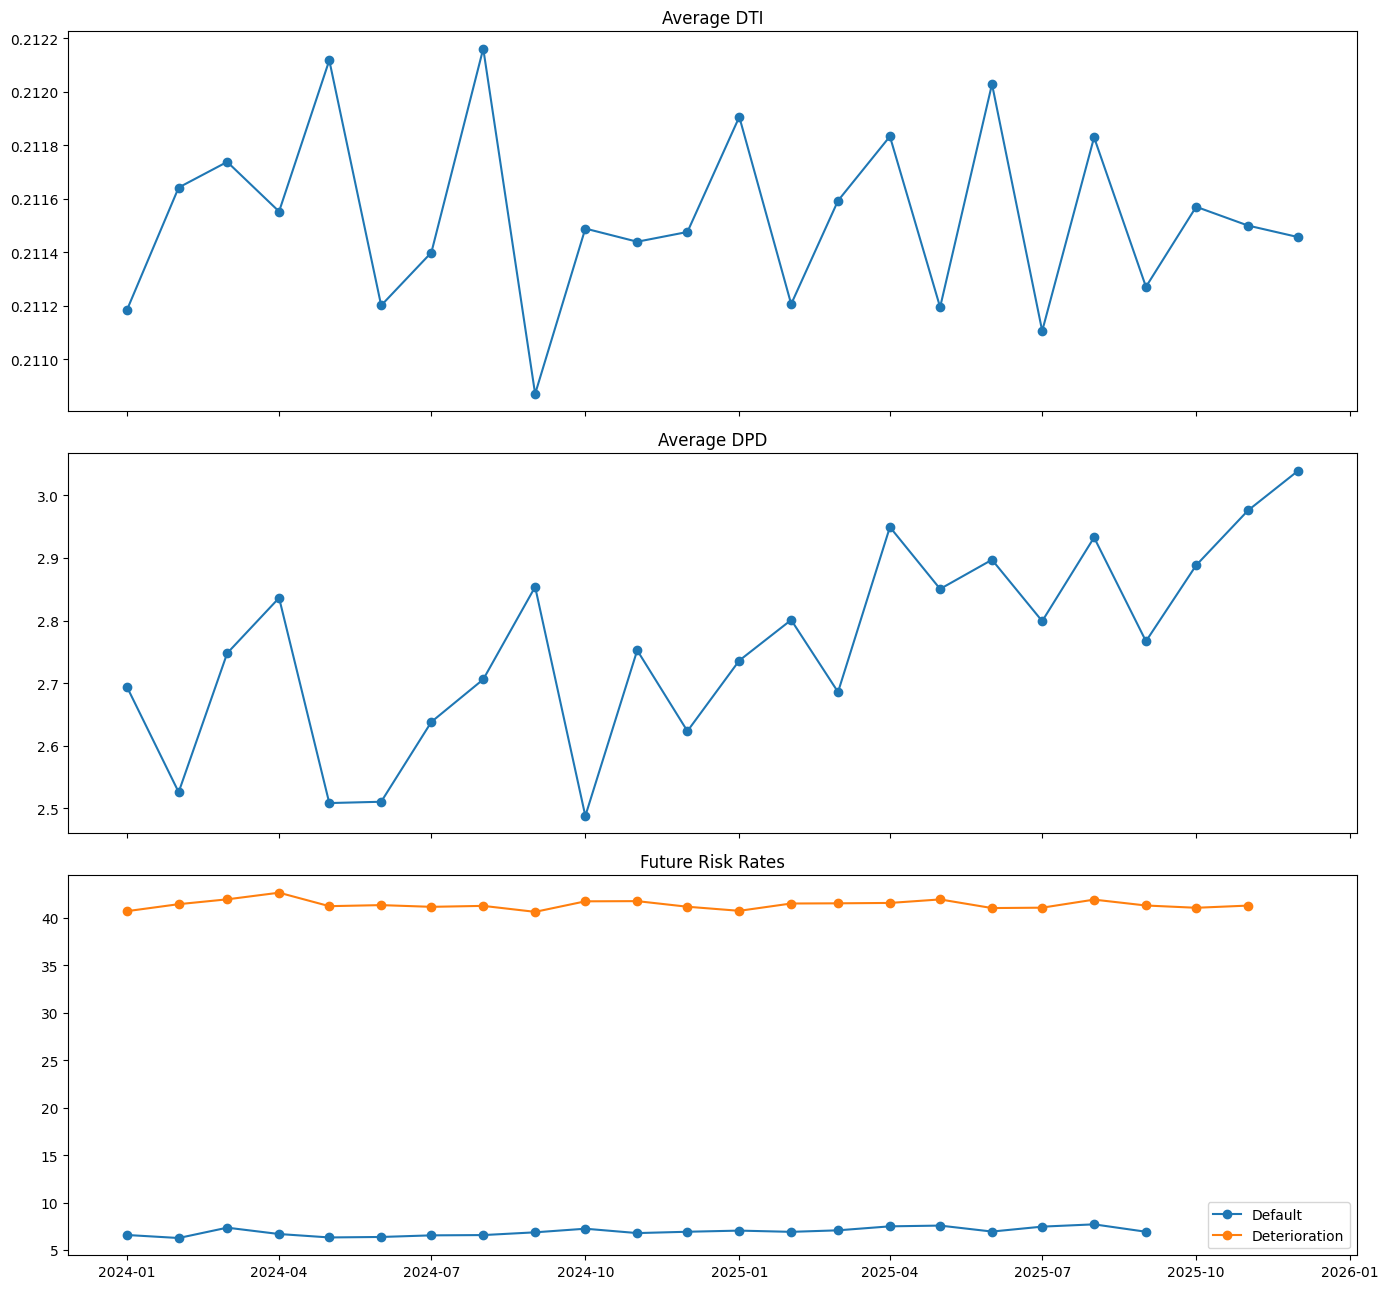

In [11]:
# Temporal trends
temporal=(behavior.groupby("snapshot_date")
          .agg(avg_dti=("dti","mean"),
               avg_dpd=("dpd","mean"),
               avg_utilization=("utilization","mean"),
               default_rate=("default_next_3m","mean"),
               deterioration_rate=("deterioration_next_1m","mean"))
          .reset_index())

fig,axes=plt.subplots(3,1,figsize=(14,13),sharex=True)
axes[0].plot(temporal.snapshot_date,temporal.avg_dti,marker="o"); axes[0].set_title("Average DTI")
axes[1].plot(temporal.snapshot_date,temporal.avg_dpd,marker="o"); axes[1].set_title("Average DPD")
axes[2].plot(temporal.snapshot_date,temporal.default_rate*100,marker="o",label="Default")
axes[2].plot(temporal.snapshot_date,temporal.deterioration_rate*100,marker="o",label="Deterioration")
axes[2].legend(); axes[2].set_title("Future Risk Rates")
plt.tight_layout(); plt.show()

## 4. Feature Engineering

In [12]:
# Account aggregation and customer context
account_agg=(account.groupby("customer_id")
            .agg(account_count=("account_id","nunique"),
                 account_total_limit=("credit_limit","sum"),
                 account_total_outstanding=("current_outstanding","sum"),
                 account_avg_interest=("interest_rate","mean"),
                 account_total_installment=("monthly_installment","sum"),
                 collateral_total_value=("collateral_value","sum"))
            .reset_index())

profile=customer[["customer_id","age","years_employed","dependents"]].copy()

fe=behavior.sort_values(["customer_id","snapshot_date"]).copy()
fe=fe.merge(account_agg,on="customer_id",how="left")
fe=fe.merge(profile,on="customer_id",how="left")

base_temporal=[
"monthly_income","monthly_debt_payment","dti","dsr","dpd",
"late_payment_count_3m","missed_payment_count_3m","payment_ratio",
"total_credit_limit","total_outstanding","utilization",
"active_credit_accounts","new_credit_accounts_3m"]

# Lag + change
for col in base_temporal:
    fe[f"{col}_lag_1m"]=fe.groupby("customer_id")[col].shift(1)
    fe[f"{col}_change_1m"]=fe[col]-fe[f"{col}_lag_1m"]

# Historical rolling — shift BEFORE rolling to avoid current-period contamination
for col in ["dti","dpd","utilization","monthly_income","payment_ratio","total_outstanding"]:
    prior=fe.groupby("customer_id")[col].shift(1)
    g=prior.groupby(fe.customer_id)
    fe[f"{col}_avg_3m"]=g.transform(lambda s:s.rolling(3,min_periods=1).mean())
    fe[f"{col}_max_3m"]=g.transform(lambda s:s.rolling(3,min_periods=1).max())

# Directional risk signals
fe["dti_increasing"]=(fe.dti_change_1m>0).astype(int)
fe["dpd_increasing"]=(fe.dpd_change_1m>0).astype(int)
fe["utilization_increasing"]=(fe.utilization_change_1m>0).astype(int)
fe["income_decreasing"]=(fe.monthly_income_change_1m<0).astype(int)

fe["payment_stress_flag"]=(
    (fe.dpd>0)|(fe.missed_payment_count_3m>0)|(fe.payment_ratio<.95)
).astype(int)
fe["high_utilization_flag"]=(fe.utilization>=.70).astype(int)
fe["high_dti_flag"]=(fe.dti>=.40).astype(int)

fe["deterioration_signal_count"]=(
    fe.dti_increasing+fe.dpd_increasing+fe.utilization_increasing+
    fe.income_decreasing+fe.payment_stress_flag)

fe["income_vs_3m_avg"]=fe.monthly_income/fe.monthly_income_avg_3m.replace(0,np.nan)
fe["dti_vs_3m_avg"]=fe.dti/fe.dti_avg_3m.replace(0,np.nan)
fe["utilization_vs_3m_avg"]=fe.utilization/fe.utilization_avg_3m.replace(0,np.nan)

print("Engineered shape:",fe.shape)

Engineered shape: (240000, 75)


## 5. Feature Selection

In [13]:
targets=["default_next_3m","deterioration_next_1m"]
ids=["customer_id","snapshot_date"]

candidates=[c for c in fe.columns if c not in ids+targets and pd.api.types.is_numeric_dtype(fe[c])]
missing=fe[candidates].isna().mean()
candidates=missing[missing<=.40].index.tolist()

print("Candidates after missingness:",len(candidates))
display(missing.sort_values(ascending=False).head(20))

Candidates after missingness: 71


,0
late_payment_count_3m_lag_1m,0.041667
late_payment_count_3m_change_1m,0.041667
missed_payment_count_3m_lag_1m,0.041667
missed_payment_count_3m_change_1m,0.041667
payment_ratio_lag_1m,0.041667
payment_ratio_change_1m,0.041667
monthly_income_lag_1m,0.041667
monthly_income_max_3m,0.041667
payment_ratio_avg_3m,0.041667
payment_ratio_max_3m,0.041667


In [14]:
# Redundancy
cm=fe[candidates].corr().abs()
upper=cm.where(np.triu(np.ones(cm.shape),k=1).astype(bool))
high_corr=(upper.stack().reset_index()
           .rename(columns={"level_0":"feature_1","level_1":"feature_2",0:"abs_corr"})
           .query("abs_corr>=.85").sort_values("abs_corr",ascending=False))
display(high_corr.head(30))

,feature_1,feature_2,abs_corr
521,total_credit_limit,account_total_limit,1.000000
545,total_credit_limit,total_credit_limit_lag_1m,1.000000
884,account_total_limit,total_credit_limit_lag_1m,1.000000
724,active_credit_accounts,active_credit_accounts_lag_1m,1.000000
2210,monthly_income_avg_3m,monthly_income_max_3m,0.999022
2268,total_outstanding_avg_3m,total_outstanding_max_3m,0.998417
1294,monthly_income_lag_1m,monthly_income_avg_3m,0.997412
1927,total_outstanding_lag_1m,total_outstanding_avg_3m,0.996596
1295,monthly_income_lag_1m,monthly_income_max_3m,0.996285
2175,utilization_avg_3m,utilization_max_3m,0.995634


In [15]:
# Mutual information
def mi_rank(target):
    tmp=fe.loc[fe[target].notna(),candidates+[target]].copy()
    X=tmp[candidates].replace([np.inf,-np.inf],np.nan).fillna(tmp[candidates].median())
    y=tmp[target].astype(int)
    mi=mutual_info_classif(X,y,random_state=42)
    return pd.DataFrame({"feature":candidates,"MI":mi}).sort_values("MI",ascending=False)

mi_credit=mi_rank("default_next_3m")
mi_early=mi_rank("deterioration_next_1m")
display(mi_credit.head(20))
display(mi_early.head(20))

,feature,MI
8,total_credit_limit,0.056997
14,account_total_limit,0.056907
17,account_total_installment,0.056180
15,account_total_outstanding,0.056125
38,total_credit_limit_lag_1m,0.054336
7,payment_ratio,0.048238
56,payment_ratio_avg_3m,0.040986
6,missed_payment_count_3m,0.037071
57,payment_ratio_max_3m,0.035153
48,dti_avg_3m,0.034889


,feature,MI
8,total_credit_limit,0.019864
17,account_total_installment,0.019045
4,dpd,0.018611
38,total_credit_limit_lag_1m,0.018528
15,account_total_outstanding,0.018218
62,utilization_increasing,0.018018
14,account_total_limit,0.017855
7,payment_ratio,0.017640
60,dti_increasing,0.017396
63,income_decreasing,0.017303


In [16]:
# Final business-driven feature sets
credit_features=[
"monthly_income","monthly_debt_payment","dti","dsr",
"dpd","late_payment_count_3m","missed_payment_count_3m","payment_ratio",
"total_credit_limit","total_outstanding","utilization",
"active_credit_accounts","new_credit_accounts_3m",
"age","years_employed","dependents",
"dti_change_1m","dpd_change_1m","utilization_change_1m","monthly_income_change_1m",
"dti_avg_3m","dpd_avg_3m","utilization_avg_3m","income_vs_3m_avg",
"payment_stress_flag","high_utilization_flag","high_dti_flag"]

early_features=[
"monthly_income","monthly_debt_payment","dti","dsr",
"dpd","late_payment_count_3m","missed_payment_count_3m","payment_ratio",
"total_credit_limit","total_outstanding","utilization",
"active_credit_accounts","new_credit_accounts_3m",
"age","years_employed","dependents",
"monthly_income_change_1m","dti_change_1m","dpd_change_1m",
"utilization_change_1m","payment_ratio_change_1m",
"dti_avg_3m","dti_max_3m","dpd_avg_3m","dpd_max_3m",
"utilization_avg_3m","utilization_max_3m","monthly_income_avg_3m",
"income_vs_3m_avg","dti_vs_3m_avg","utilization_vs_3m_avg",
"dti_increasing","dpd_increasing","utilization_increasing",
"income_decreasing","payment_stress_flag","high_utilization_flag",
"high_dti_flag","deterioration_signal_count"]

credit_features=[c for c in credit_features if c in fe.columns]
early_features=[c for c in early_features if c in fe.columns]

print("Credit Risk feature count:",len(credit_features))
print("Early Warning feature count:",len(early_features))

Credit Risk feature count: 27
Early Warning feature count: 39


## 6. Modeling Setup — Temporal Split

In [17]:
TRAIN_END=pd.Timestamp("2024-12-01")
VAL_END=pd.Timestamp("2025-04-01")
TEST_END=pd.Timestamp("2025-09-01")

def temporal_split(df,target):
    d=df[df[target].notna()].copy()
    tr=d[d.snapshot_date<=TRAIN_END]
    va=d[(d.snapshot_date>TRAIN_END)&(d.snapshot_date<=VAL_END)]
    te=d[(d.snapshot_date>VAL_END)&(d.snapshot_date<=TEST_END)]
    return tr,va,te

def threshold_f1(y,p):
    ts=np.arange(.05,.96,.01)
    scores=[f1_score(y,p>=t) for t in ts]
    return float(ts[int(np.argmax(scores))])

def metrics(y,p,t):
    pred=(p>=t).astype(int)
    return {
        "F1":f1_score(y,pred),
        "ROC_AUC":roc_auc_score(y,p),
        "PR_AUC":average_precision_score(y,p),
        "Precision":precision_score(y,pred,zero_division=0),
        "Recall":recall_score(y,pred,zero_division=0),
        "Accuracy":accuracy_score(y,pred),
        "Threshold":t
    }

def models(y):
    scale=(y==0).sum()/max((y==1).sum(),1)
    m={
    "Logistic Regression":Pipeline([
        ("imputer",SimpleImputer(strategy="median")),
        ("scaler",StandardScaler()),
        ("model",LogisticRegression(max_iter=1000,class_weight="balanced",random_state=42))
    ]),
    "Random Forest":Pipeline([
        ("imputer",SimpleImputer(strategy="median")),
        ("model",RandomForestClassifier(
            n_estimators=100,max_depth=10,min_samples_leaf=5,
            class_weight="balanced_subsample",n_jobs=-1,random_state=42))
    ])}
    if XGB_AVAILABLE:
        m["XGBoost"]=Pipeline([
            ("imputer",SimpleImputer(strategy="median")),
            ("model",XGBClassifier(
                n_estimators=300,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.85,
                colsample_bytree=0.85,

                objective="binary:logistic",
                eval_metric="logloss",

                scale_pos_weight=scale,

                tree_method="hist",
                device="cuda",

                n_jobs=-1,
                random_state=42)
                )
        ])
    return m

def experiment(df,features,target,label):
    tr,va,te=temporal_split(df,target)
    Xtr,ytr=tr[features],tr[target].astype(int)
    Xv,yv=va[features],va[target].astype(int)
    Xt,yt=te[features],te[target].astype(int)
    rows=[]; fitted={}
    for name,model in models(ytr).items():
        model.fit(Xtr,ytr)
        pv=model.predict_proba(Xv)[:,1]
        th=threshold_f1(yv,pv)
        pt=model.predict_proba(Xt)[:,1]
        r=metrics(yt,pt,th)
        r.update({"Experiment":label,"Model":name})
        rows.append(r); fitted[name]=model
    return pd.DataFrame(rows),fitted

print("Temporal split:",TRAIN_END,VAL_END,TEST_END)

Temporal split: 2024-12-01 00:00:00 2025-04-01 00:00:00 2025-09-01 00:00:00


## 7. Credit Risk — Baseline vs Feature Engineering

In [18]:
credit_baseline=[
"monthly_income","monthly_debt_payment","dti","dsr",
"dpd","late_payment_count_3m","missed_payment_count_3m",
"payment_ratio","total_credit_limit","total_outstanding",
"utilization","active_credit_accounts","new_credit_accounts_3m",
"age","years_employed","dependents"]

cr_base,cr_base_models=experiment(fe,credit_baseline,"default_next_3m","Credit Risk — Baseline")
cr_fe,cr_fe_models=experiment(fe,credit_features,"default_next_3m","Credit Risk — Feature Engineering")
cr_results=pd.concat([cr_base,cr_fe],ignore_index=True)

display(cr_results.sort_values(["F1","ROC_AUC"],ascending=False))

,F1,ROC_AUC,PR_AUC,Precision,Recall,Accuracy,Threshold,Experiment,Model
3,0.473454,0.827389,0.446481,0.488379,0.459415,0.92522,0.81,Credit Risk — Feature Engineering,Logistic Regression
5,0.473022,0.823783,0.438861,0.484120,0.462421,0.92460,0.79,Credit Risk — Feature Engineering,XGBoost
0,0.469797,0.824091,0.442012,0.493237,0.448483,0.92592,0.81,Credit Risk — Baseline,Logistic Regression
2,0.469089,0.820064,0.437111,0.460506,0.477999,0.92082,0.76,Credit Risk — Baseline,XGBoost
4,0.467155,0.822942,0.429127,0.472844,0.461602,0.92294,0.69,Credit Risk — Feature Engineering,Random Forest
1,0.459833,0.818311,0.424886,0.485853,0.436458,0.92496,0.71,Credit Risk — Baseline,Random Forest


## 8. Early Warning — Baseline vs Feature Engineering

In [19]:
ew_baseline=[
"monthly_income","monthly_debt_payment","dti","dsr",
"dpd","late_payment_count_3m","missed_payment_count_3m",
"payment_ratio","total_credit_limit","total_outstanding",
"utilization","active_credit_accounts","new_credit_accounts_3m",
"age","years_employed","dependents"]

ew_base,ew_base_models=experiment(fe,ew_baseline,"deterioration_next_1m","Early Warning — Baseline")
ew_fe,ew_fe_models=experiment(fe,early_features,"deterioration_next_1m","Early Warning — Feature Engineering")
ew_results=pd.concat([ew_base,ew_fe],ignore_index=True)

display(ew_results.sort_values(["F1","ROC_AUC"],ascending=False))

,F1,ROC_AUC,PR_AUC,Precision,Recall,Accuracy,Threshold,Experiment,Model
3,0.586211,0.595878,0.562219,0.414655,0.999904,0.41472,0.39,Early Warning — Feature Engineering,Logistic Regression
0,0.586201,0.590979,0.558287,0.414628,1.000000,0.41464,0.38,Early Warning — Baseline,Logistic Regression
1,0.586197,0.589523,0.555926,0.414674,0.999711,0.41480,0.37,Early Warning — Baseline,Random Forest
2,0.586173,0.588351,0.555516,0.414608,0.999952,0.41460,0.27,Early Warning — Baseline,XGBoost
4,0.586163,0.594498,0.559715,0.414623,0.999807,0.41466,0.39,Early Warning — Feature Engineering,Random Forest
5,0.586107,0.593032,0.559619,0.414642,0.999373,0.41478,0.33,Early Warning — Feature Engineering,XGBoost


## 9. Final Model Comparison

,Experiment,Model,F1,ROC_AUC,PR_AUC,Precision,Recall,Accuracy,Threshold
0,Credit Risk — Baseline,Logistic Regression,0.469797,0.824091,0.442012,0.493237,0.448483,0.92592,0.81
2,Credit Risk — Baseline,XGBoost,0.469089,0.820064,0.437111,0.460506,0.477999,0.92082,0.76
1,Credit Risk — Baseline,Random Forest,0.459833,0.818311,0.424886,0.485853,0.436458,0.92496,0.71
3,Credit Risk — Feature Engineering,Logistic Regression,0.473454,0.827389,0.446481,0.488379,0.459415,0.92522,0.81
5,Credit Risk — Feature Engineering,XGBoost,0.473022,0.823783,0.438861,0.484120,0.462421,0.92460,0.79
4,Credit Risk — Feature Engineering,Random Forest,0.467155,0.822942,0.429127,0.472844,0.461602,0.92294,0.69
6,Early Warning — Baseline,Logistic Regression,0.586201,0.590979,0.558287,0.414628,1.000000,0.41464,0.38
7,Early Warning — Baseline,Random Forest,0.586197,0.589523,0.555926,0.414674,0.999711,0.41480,0.37
8,Early Warning — Baseline,XGBoost,0.586173,0.588351,0.555516,0.414608,0.999952,0.41460,0.27
9,Early Warning — Feature Engineering,Logistic Regression,0.586211,0.595878,0.562219,0.414655,0.999904,0.41472,0.39


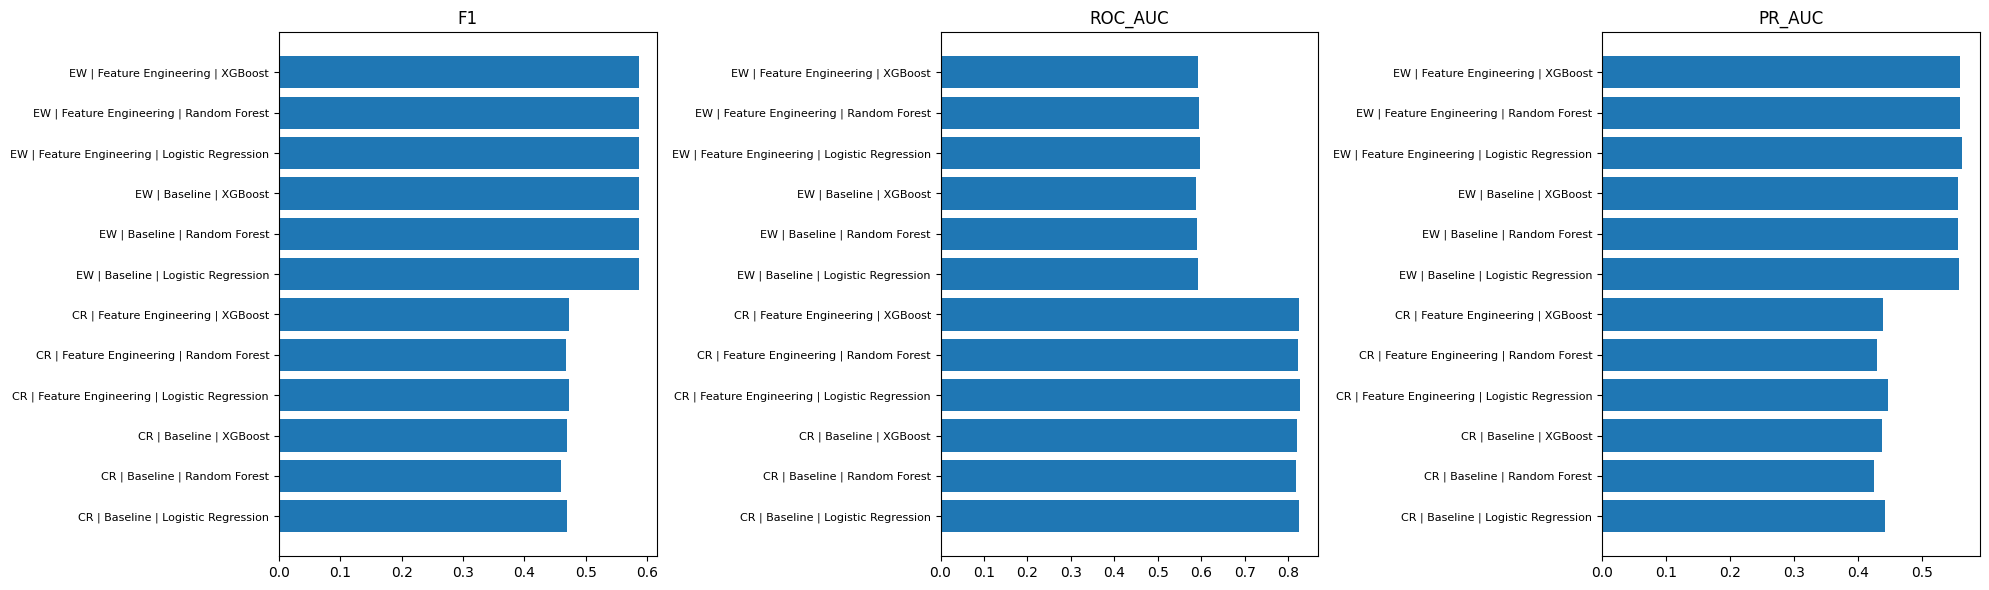

In [20]:
results=pd.concat([cr_results,ew_results],ignore_index=True)
display(results[[
"Experiment","Model","F1","ROC_AUC","PR_AUC",
"Precision","Recall","Accuracy","Threshold"
]].sort_values(["Experiment","F1"],ascending=[True,False]))

fig,axes=plt.subplots(1,3,figsize=(20,6))
for ax,metric in zip(axes,["F1","ROC_AUC","PR_AUC"]):
    x=results.copy()
    x["label"]=x.Experiment.str.replace("Credit Risk — ","CR | ").str.replace("Early Warning — ","EW | ")+" | "+x.Model
    ax.barh(x["label"],x[metric])
    ax.set_title(metric)
    ax.tick_params(axis="y",labelsize=8)
plt.tight_layout(); plt.show()

## 10. Detailed Evaluation

In [21]:
def detailed(model,features,target,threshold,title):
    _,_,test=temporal_split(fe,target)
    X=test[features]; y=test[target].astype(int)
    p=model.predict_proba(X)[:,1]; pred=(p>=threshold).astype(int)
    print(title)
    print("ROC-AUC:",round(roc_auc_score(y,p),4))
    print("PR-AUC :",round(average_precision_score(y,p),4))
    print("F1     :",round(f1_score(y,pred),4))
    print("Precision:",round(precision_score(y,pred,zero_division=0),4))
    print("Recall   :",round(recall_score(y,pred,zero_division=0),4))
    display(pd.DataFrame(confusion_matrix(y,pred),
                         index=["Actual 0","Actual 1"],
                         columns=["Pred 0","Pred 1"]))
    print(classification_report(y,pred,digits=4))

best_cr=cr_results.sort_values("F1",ascending=False).iloc[0]
if best_cr.Experiment.endswith("Baseline"):
    best_model=cr_base_models[best_cr.Model]; best_features=credit_baseline
else:
    best_model=cr_fe_models[best_cr.Model]; best_features=credit_features

detailed(best_model,best_features,"default_next_3m",best_cr.Threshold,"Best Credit Risk Model")

Best Credit Risk Model
ROC-AUC: 0.8274
PR-AUC : 0.4465
F1     : 0.4735
Precision: 0.4884
Recall   : 0.4594


,Pred 0,Pred 1
Actual 0,44580,1761
Actual 1,1978,1681


              precision    recall  f1-score   support

           0     0.9575    0.9620    0.9598     46341
           1     0.4884    0.4594    0.4735      3659

    accuracy                         0.9252     50000
   macro avg     0.7229    0.7107    0.7166     50000
weighted avg     0.9232    0.9252    0.9242     50000



In [22]:
best_ew=ew_results.sort_values("F1",ascending=False).iloc[0]
if best_ew.Experiment.endswith("Baseline"):
    best_model=ew_base_models[best_ew.Model]; best_features=ew_baseline
else:
    best_model=ew_fe_models[best_ew.Model]; best_features=early_features

detailed(best_model,best_features,"deterioration_next_1m",best_ew.Threshold,"Best Early Warning Model")

Best Early Warning Model
ROC-AUC: 0.5959
PR-AUC : 0.5622
F1     : 0.5862
Precision: 0.4147
Recall   : 0.9999


,Pred 0,Pred 1
Actual 0,7,29262
Actual 1,2,20729


              precision    recall  f1-score   support

           0     0.7778    0.0002    0.0005     29269
           1     0.4147    0.9999    0.5862     20731

    accuracy                         0.4147     50000
   macro avg     0.5962    0.5001    0.2933     50000
weighted avg     0.6272    0.4147    0.2433     50000



## 11. Feature Importance


 Credit Risk — Random Forest


,importance
payment_ratio,0.167760
dti_avg_3m,0.129360
payment_stress_flag,0.113575
dti,0.099707
missed_payment_count_3m,0.076894
late_payment_count_3m,0.062617
dsr,0.050868
dpd,0.040954
utilization,0.040214
utilization_avg_3m,0.031265


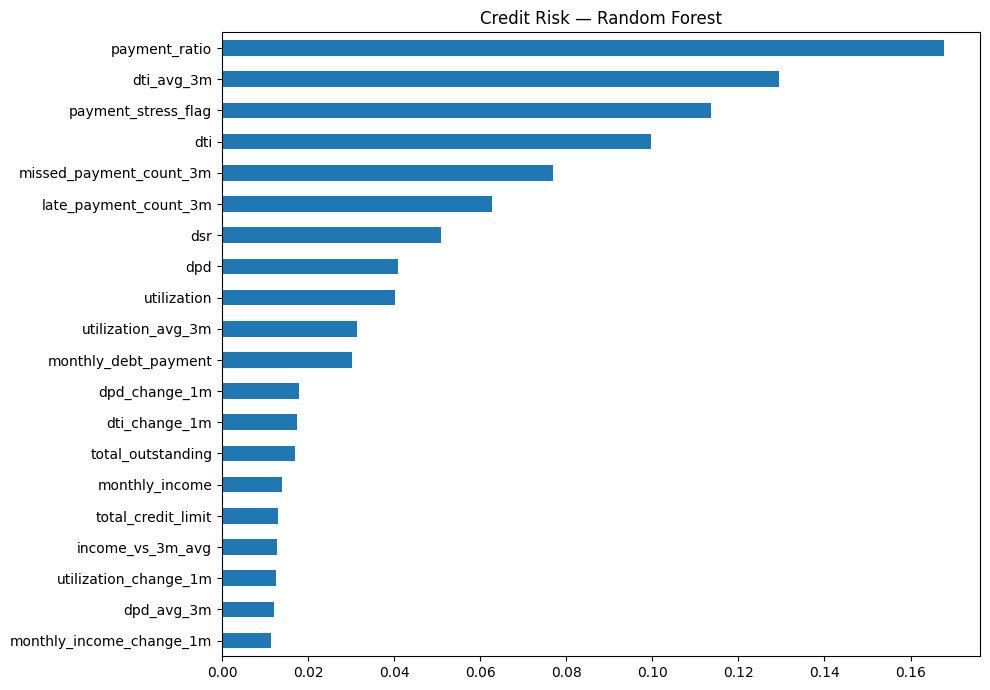


 Credit Risk — XGBoost


,importance
payment_stress_flag,0.708321
payment_ratio,0.082329
missed_payment_count_3m,0.038731
dti_avg_3m,0.017312
dpd,0.015123
late_payment_count_3m,0.012765
dti,0.012270
utilization,0.010607
utilization_avg_3m,0.008288
dsr,0.007235


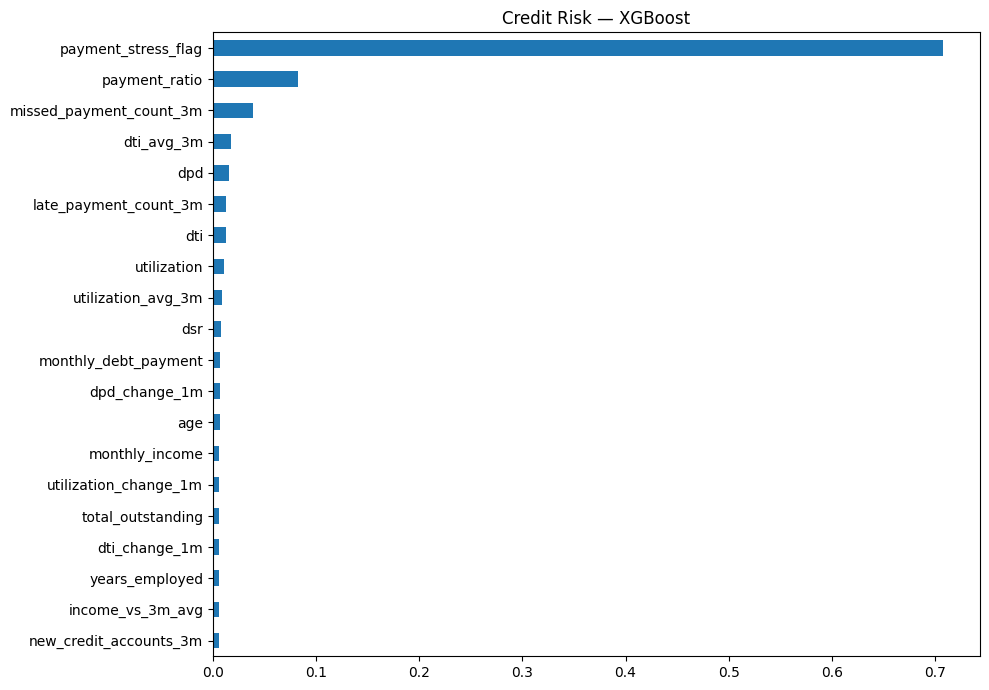


 Early Warning — Random Forest


,importance
dpd,0.135574
dpd_change_1m,0.112263
payment_ratio,0.105117
missed_payment_count_3m,0.087291
dti_avg_3m,0.060421
dpd_increasing,0.058691
dti,0.057060
dti_max_3m,0.045602
dsr,0.031536
payment_stress_flag,0.025981


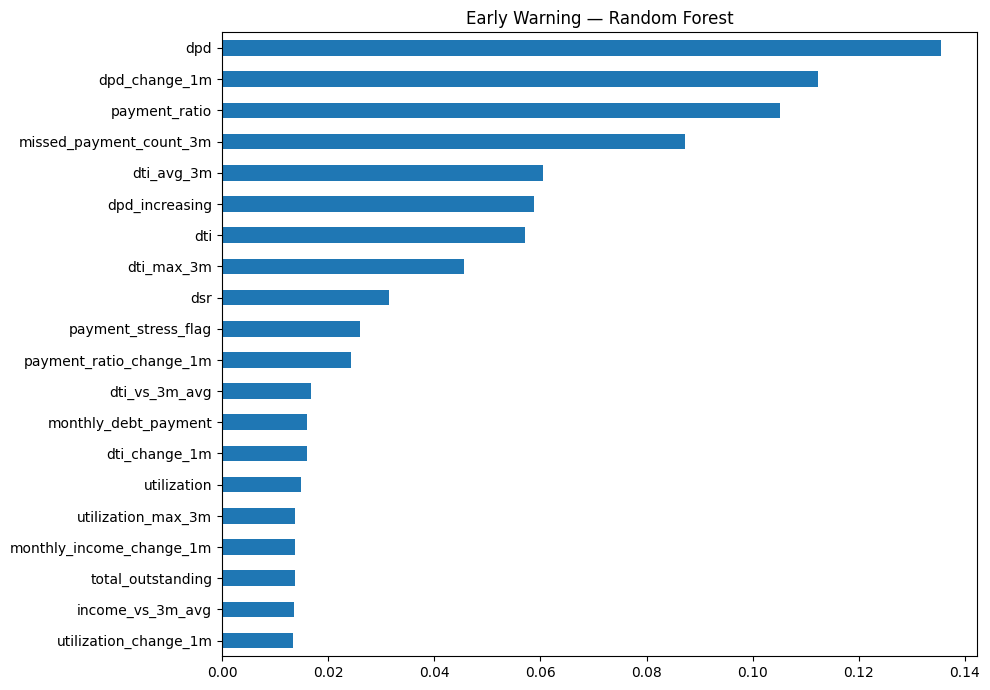


 Early Warning — XGBoost


,importance
dpd,0.278752
missed_payment_count_3m,0.193194
dti_avg_3m,0.041434
payment_ratio,0.040237
dpd_change_1m,0.039055
payment_stress_flag,0.019375
dti,0.017697
late_payment_count_3m,0.016934
utilization_increasing,0.016274
utilization_max_3m,0.013512


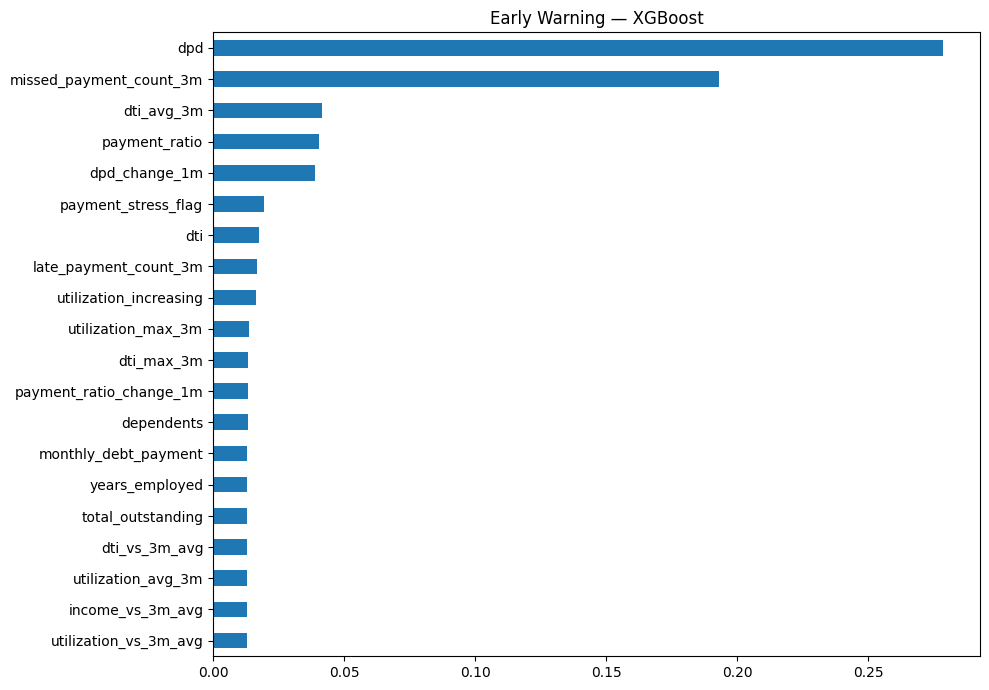

In [23]:
def tree_importance(models_dict,features,title):
    for name,m in models_dict.items():
        est=m.named_steps["model"]
        if hasattr(est,"feature_importances_"):
            imp=pd.Series(est.feature_importances_,index=features).sort_values(ascending=False).head(20)
            print("\n",title,"—",name)
            display(imp.to_frame("importance"))
            imp.sort_values().plot(kind="barh",figsize=(10,7),title=f"{title} — {name}")
            plt.tight_layout(); plt.show()

tree_importance(cr_fe_models,credit_features,"Credit Risk")
tree_importance(ew_fe_models,early_features,"Early Warning")

## 12. Save Outputs

In [24]:
credit_dataset=fe[["customer_id","snapshot_date"]+credit_features+["default_next_3m"]]
early_dataset=fe[["customer_id","snapshot_date"]+early_features+["deterioration_next_1m"]]

credit_dataset.to_csv(OUT_DIR/"credit_risk_modeling_dataset.csv",index=False)
early_dataset.to_csv(OUT_DIR/"early_warning_modeling_dataset.csv",index=False)
results.to_csv(OUT_DIR/"model_comparison_results.csv",index=False)

print("Saved files:")
for p in sorted(OUT_DIR.glob("*.csv")):
    print("-",p.name)

Saved files:
- credit_risk_modeling_dataset.csv
- early_warning_modeling_dataset.csv
- model_comparison_results.csv


# 13. Interpretation Checklist

Untuk presentasi, fokus pada:

### Credit Risk
- Apakah model bisa membedakan customer default vs non-default?
- Apakah feature engineering meningkatkan ROC-AUC / PR-AUC / F1?
- Apakah recall cukup untuk early intervention?
- Feature apa yang paling penting?

### Early Warning
- Apakah trend features membantu dibanding current-state baseline?
- Apakah DTI / DPD / utilization changes menjadi leading indicators?
- Apakah model mampu menangkap deterioration sebelum default?

### Important
**Accuracy bukan metric utama.** Karena default tetap imbalanced, prioritaskan:
1. F1
2. Recall
3. PR-AUC
4. ROC-AUC
5. Precision

Threshold juga harus dipilih berdasarkan business cost:
- False Negative = gagal mendeteksi calon default
- False Positive = analyst melakukan additional investigation

In [ ]:
ddf = pd.read_csv()